In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
# from OptiNet import OptiNet
import cvxpy as cp
from cvxpylayers.torch import CvxpyLayer
import sympy as sp
import sympy.diffgeom as dg
import torch
import torch.nn as nn
from torch.utils.data import Dataset
device = torch.device("cuda:0" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

In [75]:
#Import files
data_dir = Path("data")
episodes = []
for fp in sorted(data_dir.glob("data*.npz")):
    z = np.load(fp)
    episodes.append(z["data"]) 
len(episodes), episodes[1].shape

(27, (102, 13))

In [76]:
#Look at file data.
episode_data = episodes[2]
episode_data[100:150, :14]

array([[12.84264613, 10.20120798,  0.89952663, -2.86416256,  1.37802464,
        -1.12236116, 13.45983489, 10.02233542,  2.7137817 ,  3.11659016,
         0.0425164 ,  0.49211686,  0.02885356],
       [12.55247435, 10.33949507,  0.88176926, -2.92757008,  1.38217056,
        -1.12969871, 13.17374182, 10.152034  ,  2.7181776 ,  3.16580184,
         0.04540175,  0.50011262,  0.03377135]])

In [77]:
#Structure input files for LSTM
from copy import deepcopy
lookback = 5

def calculate_barrier_function(state, ko_data):
    #hx is CBF
    x = state[0]
    y = state[1]
    x_ko = ko_data[0]
    y_ko = ko_data[1]
    radius_ko = ko_data[2]

    hx = np.sqrt((x-x_ko)**2 + (y-y_ko)**2)-radius_ko
    return hx
     



def parse_data(data, lookback, ko_data): #TODO: Add padding so that first few values can be added to train
    data = deepcopy(data)
    X= []
    Y = []    #NN outputs force and torque, each Y_i should be accompanied with states from X_i-5 to X_i
    # print (data[1].shape)
    for i in range(len(data)): #go across all episodes  
        episode_data = data[i]
        episode_length = episode_data.shape[0]
        Y_new = episode_data[lookback:, 11:13] #Get all force and torque vectors. Ignore first 5 elements since no history
        # print("Y_new Shape", Y_new.shape)
        Y.append(Y_new)

        #Need shape (ep_length, lookback, data)
        episode_data_x = episode_data[:, 1:12] #shape 2000, 11
        for j in range(episode_length - lookback):   #TODO def not the most efficient way to parse all the data
            row_xs = []
            for k in range(lookback):
                hist_timestamp = j + k
                x_hist = episode_data_x[hist_timestamp,:]
                hx = calculate_barrier_function(x_hist, ko_data)
                x_hist = np.concatenate([x_hist, [hx]])
                row_xs.append(x_hist)
                #add X hist
            X.append(row_xs)

    #Combine data cross all episodes into one
    X= np.array(X)
    # print(Y[0].shape)
    Y = np.concatenate(Y, axis=0)
    return X, Y


#insert keep out region into training data set to calculate hf
ko_data = [5, 5, 2]    #x, y, rad

X, Y = parse_data(episodes, lookback, ko_data)
print("X Shape",X.shape)
print("Y Shape", Y.shape)
# Y[1000:1100, :]

X Shape (5969, 5, 12)
Y Shape (5969, 2)


In [78]:
#Post process data
# from sklearn.preprocessing import MinMaxScaler

# scaler = MinMaxScaler(feature_range=(-1, 1))
# X = scaler.fit_transform(X)
# Y = scaler.fit_transform(Y)

split_index = int(len(X) * 0.95)
X_train = X[:split_index]
X_test = X[split_index:]

Y_train = Y[:split_index]
Y_test = Y[split_index:]

X_train = torch.tensor(X_train).float()
Y_train = torch.tensor(Y_train).float()
X_test = torch.tensor(X_test).float()
Y_test = torch.tensor(Y_test).float()


X_train.shape, X_test.shape, Y_train.shape, Y_test.shape


(torch.Size([5670, 5, 12]),
 torch.Size([299, 5, 12]),
 torch.Size([5670, 2]),
 torch.Size([299, 2]))

In [79]:
class TrajectoryDataset(Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.X[i], self.Y[i]

train_dataset = TrajectoryDataset(X_train, Y_train)
test_dataset = TrajectoryDataset(X_test, Y_test)

from torch.utils.data import DataLoader

batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [80]:
for _, batch in enumerate(train_loader):
    x_batch, y_batch = batch[0].to(device), batch[1].to(device)
    print(x_batch.shape, y_batch.shape)
    break

torch.Size([16, 5, 12]) torch.Size([16, 2])


In [90]:
# #Optimization layer stuff
# state_mfld = dg.Manifold("M", 5)
# state_mfld_patch = dg.Patch("P", state_mfld)

# x, y, theta, v, omega = sp.symbols(r"x,y,\theta,v,\omega", real=True)

# state_mfld_coords = dg.CoordSystem(
#     "StateSpace", state_mfld_patch, (x, y, theta, v, omega)
# )

# (x_sc, y_sc, theta_sc, v_sc, omega_sc) = state_mfld_coords.base_scalars()
# (x_vec, y_vec, theta_vec, v_vec, omega_vec) = state_mfld_coords.base_vectors()

# # define the vector fields of the system

# f = (
#     v_sc * sp.cos(theta_sc) * x_vec
#     + v_sc * sp.sin(theta_sc) * y_vec
#     + omega_sc * theta_vec
# )

# f1 = v_vec
# f2 = omega_vec

# u_f, u_t = sp.symbols("u_f,u_t", real=True)

# display(f, f1, f2)
# display(u_f, u_t)

# # define the variables associated with the keep out region
# t = sp.symbols("t", real=True)

# x_ko = sp.Function("x_ko")(t)  #shows that not constant with time, x_dot != 0
# y_ko = sp.Function("y_ko")(t)
# r_ko = sp.Function("r_ko")(t)

# ko_cbf = sp.sqrt((x_sc - x_ko) ** 2 + (y_sc - y_ko) ** 2) - r_ko
# display(ko_cbf)



In [ ]:
# # generates the condition for the HOCBF


# def _repeated_lie_deriv(f, h, n):
#     if n == 0:
#         return h
#     return _repeated_lie_deriv(f, dg.LieDerivative(f, h), n - 1)


# def gen_hocbf_condition(dyn_f, dyn_gs, us, m, h, t, alpha_fns):
#     lie_m_fh = _repeated_lie_deriv(dyn_f, h, m)
#     lie_g_fh = sum(
#         dg.LieDerivative(g, _repeated_lie_deriv(f, h, m - 1)) * u
#         for (g, u) in zip(dyn_gs, us)
#     )
#     dmh_dtm = sp.diff(h, t, m)

#     alpha_fns.insert(0, lambda phi: 1.0 * phi)  # dummy to ensure correct indexing

#     phi_fns = [h]
#     for i in range(1, m):
#         phi_fns.append(sp.diff(phi_fns[i - 1], t) + alpha_fns[i](phi_fns[i - 1]))

#     o_h = 0
#     for i in range(1, m - 1):
#         # same thing here with the alpha indexing
#         alpha_phi_fn = alpha_fns[m - i](phi_fns[m - i - 1])
#         o_h += _repeated_lie_deriv(f, alpha_phi_fn, i) + sp.diff(alpha_phi_fn, t, i)

#     final_alpha_phi = alpha_fns[m](phi_fns[m - 1])

#     return lie_m_fh + lie_g_fh + dmh_dtm + o_h + final_alpha_phi


# # assuming the use of linear extended K_infty functions
# k1, k2 = sp.symbols("k1,k2", nonneg=True, real=True)

# ko_hocbf = (
#     gen_hocbf_condition(
#         f, [f1, f2], [u_f, u_t], 2, ko_cbf, t, [lambda x: k1 * x, lambda x: k2 * x]
#     )
#     .nsimplify()
#     .simplify()
# )



In [ ]:
# # devise some simplifications that might help

# x_err_sym, y_err_sym, v_err_sym, r_1_sym, r_2_sym, r_3_sym, r_4_sym, r_5_sym = (
#     sp.symbols("x_err,y_err,v_err,r_1,r_2,r_3,r_4,r_5", real=True)
# )

# x_err = x_ko - x_sc
# y_err = y_ko - y_sc
# v_err = x_err_sym**2 + y_err_sym**2

# r_1 = v_err_sym ** (sp.Rational(7 / 2)) * x_err_sym
# r_2 = v_err_sym ** (sp.Rational(7 / 2)) * y_err_sym
# r_3 = v_err_sym ** (sp.Rational(5 / 2)) * x_err_sym**2
# r_4 = v_err_sym ** (sp.Rational(5 / 2)) * y_err_sym**2
# r_5 = v_err_sym ** (sp.Rational(5 / 2)) * x_err_sym * y_err_sym

# ko_hocbf_cleaned = (
#     (ko_hocbf.subs(x_err, x_err_sym).subs(y_err, y_err_sym).subs(v_err, v_err_sym))
#     .simplify()
#     .factor()
#     .subs(r_1, r_1_sym)
#     .subs(r_2, r_2_sym)
#     .subs(r_3, r_3_sym)
#     .subs(r_4, r_4_sym)
#     .subs(r_5, r_5_sym)
# ).factor()
# ko_hocbf_condition = ko_hocbf_cleaned >= 0
# display(ko_hocbf_condition)
# display(k1)

-(-2*k1*k2*v_err**(9/2) + 2*k1*k2*v_err**4*r_ko(t) - 2*k2*r_1*Derivative(x_ko(t), t) - 2*k2*r_2*Derivative(y_ko(t), t) + 2*k2*v_err**4*Derivative(r_ko(t), t) + 2*r_1*u_f*cos(\theta) - 2*r_1*sin(\theta)*v*\omega - 2*r_1*Derivative(x_ko(t), (t, 2)) + 2*r_2*u_f*sin(\theta) + 2*r_2*cos(\theta)*v*\omega - 2*r_2*Derivative(y_ko(t), (t, 2)) + r_3*cos(2*\theta)*v**2 + r_3*v**2 + 2*r_3*Derivative(x_ko(t), t)**2 - r_4*cos(2*\theta)*v**2 + r_4*v**2 + 2*r_4*Derivative(y_ko(t), t)**2 + 2*r_5*sin(2*\theta)*v**2 + 4*r_5*Derivative(x_ko(t), t)*Derivative(y_ko(t), t) - 2*v_err**(7/2)*v**2 - 2*v_err**(7/2)*Derivative(x_ko(t), t)**2 - 2*v_err**(7/2)*Derivative(y_ko(t), t)**2 + 2*v_err**4*Derivative(r_ko(t), (t, 2)))/(2*v_err**4) >= 0

k1

In [84]:
#TODO Add numeric values to robot state, obstacle state, 

In [ ]:
# # 1. Extract the coefficients symbolically from your cleaned condition
# # ko_hocbf_cleaned is the LHS of your inequality: A*u + b >= 0
# u_syms = [u_f, u_t]
# A_sym = sp.Matrix([ko_hocbf_cleaned]).jacobian(u_syms)
# b_sym = ko_hocbf_cleaned.subs({u_f: 0, u_t: 0})

# # 2. Convert SymPy expressions to PyTorch-compatible strings/functions
# display(A_sym)
# display(b_sym)


Matrix([[-(2*r_1*cos(\theta) + 2*r_2*sin(\theta))/(2*v_err**4), 0]])

-(-2*k1*k2*v_err**(9/2) + 2*k1*k2*v_err**4*r_ko(t) - 2*k2*r_1*Derivative(x_ko(t), t) - 2*k2*r_2*Derivative(y_ko(t), t) + 2*k2*v_err**4*Derivative(r_ko(t), t) - 2*r_1*sin(\theta)*v*\omega - 2*r_1*Derivative(x_ko(t), (t, 2)) + 2*r_2*cos(\theta)*v*\omega - 2*r_2*Derivative(y_ko(t), (t, 2)) + r_3*cos(2*\theta)*v**2 + r_3*v**2 + 2*r_3*Derivative(x_ko(t), t)**2 - r_4*cos(2*\theta)*v**2 + r_4*v**2 + 2*r_4*Derivative(y_ko(t), t)**2 + 2*r_5*sin(2*\theta)*v**2 + 4*r_5*Derivative(x_ko(t), t)*Derivative(y_ko(t), t) - 2*v_err**(7/2)*v**2 - 2*v_err**(7/2)*Derivative(x_ko(t), t)**2 - 2*v_err**(7/2)*Derivative(y_ko(t), t)**2 + 2*v_err**4*Derivative(r_ko(t), (t, 2)))/(2*v_err**4)

In [195]:
class LSTM(nn.Module):

    # input size = number features = 11
    #hidden size can be anything, use 20 for now
    #num_stacked_layers, idk what it does
    def __init__(self, input_size, hidden_size, num_stacked_layers):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_stacked_layers = num_stacked_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_stacked_layers,
                            batch_first=True)
        self.fc = nn.Linear(hidden_size, 2)

        u_f = cp.Variable(1)   #TODO: see if possible to move to init
        A = cp.Parameter(1)
        b = cp.Parameter(1)
        u_f_nom_param = cp.Parameter(1)
        constraints = [A * u_f + b >= 0]
        objective = cp.Minimize(0.5 * cp.pnorm(u_f-u_f_nom_param, p=2))
        problem = cp.Problem(objective, constraints)
        assert problem.is_dpp()

        self.layer = CvxpyLayer(problem, parameters=[A, b, u_f_nom_param], variables=[u_f])
        self.layer = self.layer.float()

    def get_cbf_coeff(self, state, ko_data, k1, k2): 
        
        #x shape torch.Size([16, 5, 12])
        current_state = state[:, -1, :]  #only want last time of LSTM

        x = current_state[:,0]
        y = current_state[:,1]
        theta = current_state[:,2]
        v = current_state[:,3]
        omega = current_state[:,4]
        x_ko = ko_data[0]
        y_ko = ko_data[1]
        r_ko = ko_data[2]

        print(f"State device: {state.device}")
        print(f"KO data device: {ko_data.device}")

        #helper variables
        x_err = x_ko - x
        y_err = y_ko - y
        v_err = x_err**2 + y_err**2

        r1 = (v_err**(7/2)) * x_err
        r2 = (v_err**(7/2)) * y_err
        r3 = (v_err**(5/2)) * (x_err**2)
        r4 = (v_err**(5/2)) * (y_err**2)
        r5 = (v_err**(5/2)) * x_err * y_err

        #Coeff for input
        u_f_coeff = (2*r1*torch.cos(theta) + 2*r2*torch.sin(theta)) / 2 * v_err**4

        #other coeffs
        term1 = -2 * k1 * k2 * (v_err**(9/2))
        term2 = 2 * k1 * k2 * v_err**4 * r_ko
        term3 = -2 * r1 * torch.sin(theta) * v * omega
        term4 = 2 * r2 * torch.cos(theta) * v * omega
        term5 = r3 * torch.cos(2 * theta) * (v**2)
        term6 = r3 * (v**2)
        term7 = -r4 * torch.cos(2 * theta) * (v**2) 
        term8 = r4 * (v**2)
        term9 = 2 * r5 * torch.sin(2 * theta) * (v**2)
        term10 = -2 * (v_err**(7/2)) * (v**2)

        numerator = -(term1 + term2 + term3 + term4 + term5 + 
                        term6 + term7 + term8 + term9 + term10)

        denominator = 2 * v_err**4

        const_coeff = numerator / denominator

        return u_f_coeff, const_coeff



    def forward(self, x, ko_data, k1, k2):
        print("x shape" ,x.shape)
        batch_size = x.size(0)
        h0 = torch.zeros(self.num_stacked_layers, batch_size, self.hidden_size).to(device)
        c0 = torch.zeros(self.num_stacked_layers, batch_size, self.hidden_size).to(device)

        out, _ = self.lstm(x, (h0, c0))
        print("out shape 1", out.shape)

        out = self.fc(out[:, -1, :]) # get only last value in LSTM output
        print("out shape 2", out.shape)
        u_f_nom = out[:, 0:1].to(torch.float32)  #keep 16, 1 shape
        

        u_f_coeff, const_coeff = self.get_cbf_coeff(x, ko_data, k1, k2)

        
        A_tch = u_f_coeff.to(device).float().reshape(-1, 1) #add extra dim for cvxpylayers
        b_tch = const_coeff.to(device).float().reshape(-1, 1)


        # solve the problem
        (solution,) = self.layer(A_tch, b_tch, u_f_nom)


        return solution 

model = LSTM(12, 20, 1)

model.to(device)
model

/Users/jiaanli/miniforge3/envs/cbf/lib/python3.13/site-packages/cvxpy/expressions/expression.py:683: UserWarning: 
This use of ``*`` has resulted in matrix multiplication.
Using ``*`` for matrix multiplication has been deprecated since CVXPY 1.1.
    Use ``*`` for matrix-scalar and vector-scalar multiplication.
    Use ``@`` for matrix-matrix and matrix-vector multiplication.
    Use ``multiply`` for elementwise multiplication.
This code path has been hit 2 times so far.

  warnings.warn(msg, UserWarning)


NotImplementedError: Could not run 'new_compressed_tensor' from the 'mps:0' device.)

In [196]:
loss_function = nn.MSELoss()
learning_rate = 0.001
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
num_epochs = 10
k1 = torch.tensor([1])
k2 = torch.tensor([1])



def train_one_epoch():
    model.train(True)
    print(f'Epoch: {epoch + 1}')
    running_loss = 0.0

    for batch_index, batch in enumerate(train_loader):

        x_batch, y_batch = batch[0].to(device), batch[1].to(device) #make things on device
        ko_data_torch = torch.tensor(ko_data)
        ko_data_torch = ko_data_torch.to(device)
        k1_torch = k1.to(device)
        k2_torch = k2.to(device)

        output = model(x_batch, ko_data_torch, k1_torch, k2_torch)     
        loss = loss_function(output, y_batch)
        running_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch_index % 100 == 99:  # print every 100 batches
            avg_loss_across_batches = running_loss / 100
            print('Batch {0}, Loss: {1:.3f}'.format(batch_index+1,
                                                    avg_loss_across_batches))
            running_loss = 0.0
    print()

def validate_one_epoch():
    model.train(False)
    running_loss = 0.0

    for batch_index, batch in enumerate(test_loader):
        x_batch, y_batch = batch[0].to(device), batch[1].to(device)

        with torch.no_grad():
            output = model(x_batch, ko_data, k1, k2)
            loss = loss_function(output, y_batch)
            running_loss += loss.item()

    avg_loss_across_batches = running_loss / len(test_loader)

    print('Val Loss: {0:.3f}'.format(avg_loss_across_batches))
    print('***************************************************')
    print()

In [197]:
for epoch in range(num_epochs):
    train_one_epoch()
    validate_one_epoch()

    

Epoch: 1
x shape torch.Size([16, 5, 12])
out shape 1 torch.Size([16, 5, 20])
out shape 2 torch.Size([16, 2])
State device: mps:0
KO data device: mps:0


NotImplementedError: Could not run 'new_compressed_tensor' from the 'mps:0' device.)

In [ ]:
with torch.no_grad():
    predicted = model(X_train.to(device)).to('cpu').numpy()


plt.plot(Y_train[:,0], label='Actual force')
plt.plot(predicted[:,0], label='Predicted force')
plt.xlabel('t')
plt.ylim(-10, 10)
plt.ylabel('force')
plt.legend()
plt.show()


In [141]:
with torch.no_grad():
    predicted = model(X_train.to(device)).to('cpu').numpy()


plt.plot(Y_train[:,1], label='Actual torque')
plt.plot(predicted[:,1], label='Predicted torque')
plt.xlabel('t')
plt.ylabel('torque')
plt.ylim(-10, 10)
plt.legend()
plt.show()

TypeError: LSTM.forward() missing 3 required positional arguments: 'ko_data', 'k1', and 'k2'

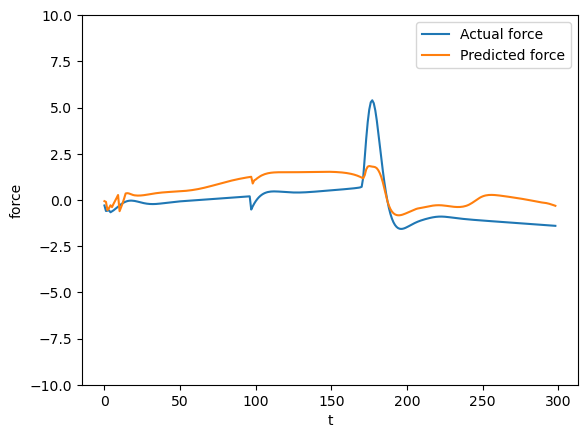

In [ ]:
#Test data

with torch.no_grad():
    predicted = model(X_test.to(device)).to('cpu').numpy()


plt.plot(Y_test[:,0], label='Actual force')
plt.plot(predicted[:,0], label='Predicted force')
plt.xlabel('t')
plt.ylim(-10, 10)
plt.ylabel('force')
plt.legend()
plt.show()